# CS3033 – Data Mining
## In-Class Programming Assessment

**Duration:** 1.5 hours

All the assignment's details are in the prited document.

**Open book: access to Canvas and offline files is permitted.**

**Websites permitted: https://pandas.pydata.org/docs/ and https://scikit-learn.org/stable/**

**Every other website is forbidden. In case of an accidental access, notify immediately the invigilators.**

**No GenAI tools permitted. Neither GenAI Functionalities of Colab! Be sure to deactivate them.**  

**No Google searches permitted.**

**Invigilators can check your computer at any time.**

**Your traffic is monitored!!**



**Any violation of the above policies will be persecuted following UCC plagiarism regulations**

**Submit:** this notebook file to Canvas

---
### Student details

**Name:** Max Warriner  
**Student ID:** 126104460  
**Lab machine number:** 14


In [36]:
import pandas as pd

url = "https://drive.google.com/uc?export=download&id=1YoBwcWmtdptZxJBU-ihUxXrg5kMqxz-c"

df = pd.read_csv(url)
df.head()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## 1. Data Preparation and Design Choices


In [37]:
# Your code here

print(df.shape)

print()

print(df.columns)

print()

print(df['price_range'].value_counts())

y = df['price_range']
X = df.drop(columns=['price_range'])



(2000, 21)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


**Short answer to Q1:**
Yes, the dataset is balanced because there is an equal number of samples per price range.


## 2. Initial Model Training


In [42]:
# Your code here

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5)

neigh.fit(X_train, y_train)

print('Test Set Accuracy =', neigh.score(X_test, y_test))

print('Baseline Accuracy =', 500/2000)

Test Set Accuracy = 0.9183333333333333
Baseline Accuracy = 0.25


**Short answer to Q2:**

Yes, the model performs better than the baseline classifier. Each group makes up 25% of the data so we'd expect the baseline accuracy to be 25% if the classifier always assigns the predictions to a single group.

**Short answer to Q3:**

Because the variable we're classifying on is ordinal, a regression model could be used to approximate the price range, but it wouldn't be optimal since the groups might not be equally spaced as they are ordinally.


## 3. Advanced Model Evaluation


{'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Test Set Accuracy = 0.5566666666666666


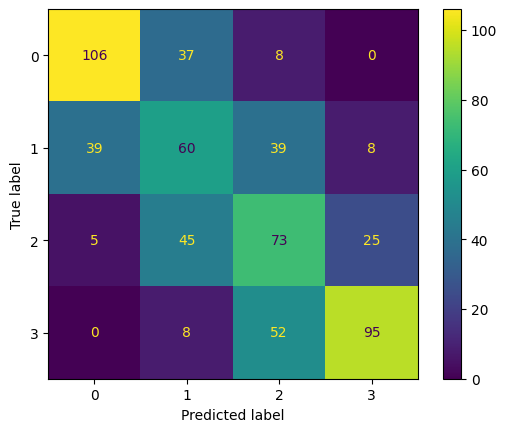

In [43]:
# Your code here

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier()),
])

param_grid = {
    "knn__n_neighbors":  [3, 5, 7],
    "knn__weights":      ["uniform", "distance"],
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = 5,
    refit      = True,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(grid_search.best_params_)

print('Test Set Accuracy =', best_model.score(X_test, y_test))

from sklearn.metrics import ConfusionMatrixDisplay

print(ConfusionMatrixDisplay.from_estimator(
        best_model,
        X_test,
        y_test,
    ))

**Short answer to Q4:**

Feature scaling is important because of the euclidean distance calculations done for the knn model. Variables with higher magnitude scales dominate the distance calculations and therefore dominate the relevance for the prediction.

**Short answer to Q5:**

This confusion matrix makes sense with the classifying variable being ordinal, because a very high cost phone and a low cost phone were never classified as each other. The model is best at classifying the low cost and very high cost phones compared to the medium cost and high cost phones. We can assume this is because phones in the medium-high cost range have two other groups adjacent to them they could be apart of and so it is often hard to distinguish them from one step lower or higher in price.


---

## Final checklist before submission

- [X] I filled in my name, student ID, and lab machine number
- [X] All work is contained in this notebook
- [X] All my code cells run
- [X] The outputs are visible
- [X] I did not use Generative AI
- [X] I submitted the correct notebook on Canvas